In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("wandb_export_2026-06-10T11_24_00.490+02_00.csv")
df = df[["delay_k", "efference_length", "episode_reward/mean"]]
df["with_efference_copy"] = df.efference_length>0
df = df[np.logical_or(df.efference_length==0, df.efference_length==df.delay_k)]

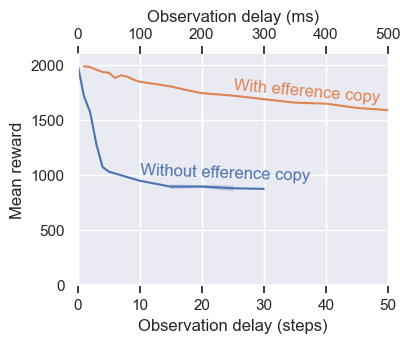

In [59]:
plt.figure(figsize=(4,3))
sns.set_theme()
plt.ylim(0, 2100)
plt.xlim(0, 50)
ax1 = plt.gca()
ax2 = plt.gca().twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(ax1.get_xticks())
ax2.set_xticklabels([int(x*10) for x in ax1.get_xticks()])
ax1.set_xlabel("Observation delay (steps)")
ax2.set_xlabel("Observation delay (ms)")
sns.lineplot(df, x="delay_k", y="episode_reward/mean", hue="with_efference_copy", legend=False)
ax1.set_ylabel("Mean reward")
plt.annotate("With efference copy", (25, 1660), color="C1", rotation=-5)
plt.annotate("Without efference copy", (10, 950), color="C0", rotation=-2)
sns.despine()